# Scheduler Comparison Experiments

This notebook runs and compares different scheduling strategies in OpenDC:

## Schedulers Tested
- **Baseline Random**: Randomly assigns tasks to available hosts
- **Baseline Memory**: Prioritizes hosts based on available memory
- **Workflow-Aware**: Considers task dependencies and critical paths
- **Carbon-Aware**: Optimizes for carbon efficiency while respecting workflows
- **Timeshift**: Delays deferrable tasks during high carbon intensity periods

## Analysis Sections
1. **Setup & Configuration** - Load libraries and configure experiments
2. **Workload Analysis** - Understand the workflow structure
3. **Run Experiments** - Execute all scheduler configurations
4. **Load & Process Results** - Import experimental data
5. **Function Definitions** - Reusable visualization and analysis functions
6. **Comparative Analysis** - Metrics, charts, and scheduler comparisons
7. **Export Results** - Save data for further analysis

In [1]:
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

---
## 1. Workload Analysis

Visualize the workflow structure and statistics.

Workload: carbon_test_long_n120_edge_prob0.3_seed1_deadline_default


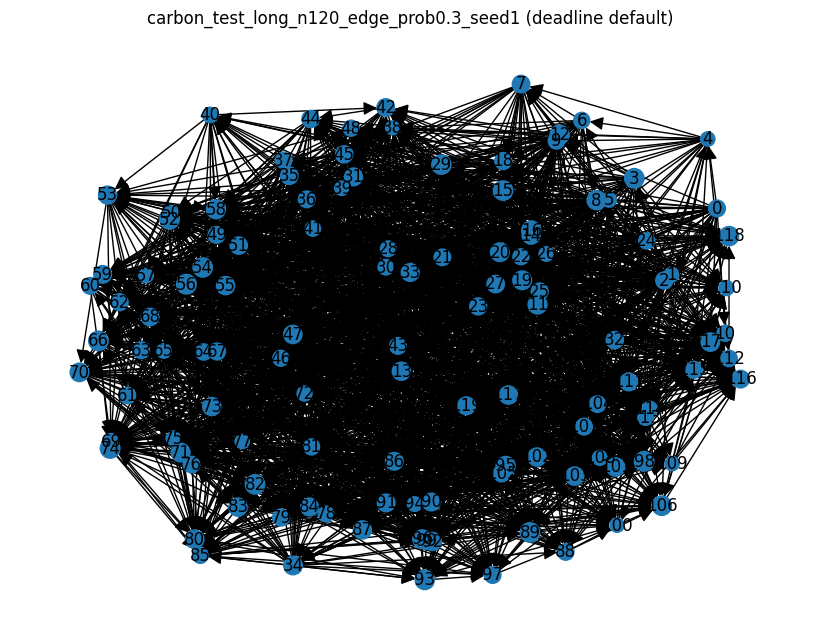

In [2]:
from IPython.display import Image, display
import json

# Read workload path from the experiment configuration
config_file = "../configs/baseline/baseline_random_experiment.json"
with open(config_file, 'r') as f:
    config = json.load(f)
    workload_relative_path = config['workloads'][0]['pathToFile']
    workload_name = workload_relative_path.split('/')[-1]
    workload_path = f"../../{workload_relative_path}"

print(f"Workload: {workload_name}")
print("="*60)

# Display the workflow DAG visualization
dag_image_path = f"{workload_path}/dag.png"
display(Image(filename=dag_image_path))

In [3]:
# Load and display workflow statistics
tasks_df = pd.read_parquet(f"{workload_path}/tasks.parquet")

print("\nWorkflow Statistics:")
print("="*60)
print(f"Total Tasks: {len(tasks_df)}")

# Calculate depth by analyzing parent-child relationships
def calculate_depth(task_id, tasks_df, memo=None):
    if memo is None:
        memo = {}
    if task_id in memo:
        return memo[task_id]
    
    task = tasks_df[tasks_df['id'] == task_id].iloc[0]
    if len(task['parents']) == 0:
        depth = 0
    else:
        depth = 1 + max(calculate_depth(p, tasks_df, memo) for p in task['parents'])
    
    memo[task_id] = depth
    return depth

# Add depth to each task
tasks_df['depth'] = tasks_df['id'].apply(lambda x: calculate_depth(x, tasks_df))

max_depth = tasks_df['depth'].max()
print(f"Workflow Depth: {max_depth}")

# Try to infer branching factor from task distribution
depth_counts = tasks_df.groupby('depth').size()
if len(depth_counts) > 1:
    # Estimate branching factor from ratio between consecutive levels
    branching_factors = []
    for d in range(len(depth_counts) - 1):
        if d in depth_counts.index and (d+1) in depth_counts.index:
            branching_factors.append(depth_counts[d+1] / depth_counts[d])
    if branching_factors:
        avg_branching = sum(branching_factors) / len(branching_factors)
        print(f"Average Branching Factor: {avg_branching:.1f}")

print(f"\nTask Distribution by Depth:")
print(depth_counts)

print(f"\nSample Tasks:")
print(tasks_df[['id', 'depth', 'parents', 'children', 'duration']].head(15))


Workflow Statistics:
Total Tasks: 120
Workflow Depth: 44
Average Branching Factor: 1.2

Task Distribution by Depth:
depth
0     3
1     2
2     2
3     5
4     4
5     4
6     6
7     3
8     2
9     3
10    1
11    2
12    1
13    1
14    3
15    2
16    3
17    3
18    4
19    1
20    4
21    4
22    2
23    2
24    3
25    1
26    2
27    3
28    2
29    4
30    3
31    2
32    2
33    2
34    3
35    3
36    3
37    4
38    4
39    2
40    4
41    1
42    3
43    1
44    1
dtype: int64

Sample Tasks:
    id  depth          parents  \
0    0      0               []   
1    1      1              [0]   
2    2      0               []   
3    3      2           [1, 2]   
4    4      1           [0, 2]   
5    5      0               []   
6    6      2           [1, 4]   
7    7      3  [1, 3, 4, 5, 6]   
8    8      3           [1, 6]   
9    9      3        [0, 3, 4]   
10  10      4        [0, 1, 7]   
11  11      4     [1, 4, 5, 7]   
12  12      3              [3]   
13  13      3

In [4]:
# Verify the dependency structure
print("DEPENDENCY STRUCTURE VERIFICATION")
print("="*70)

# Check parents per task
tasks_with_parents = tasks_df[tasks_df['parents'].apply(len) > 0]
parent_counts = tasks_with_parents['parents'].apply(len)

print(f"\nParent Analysis:")
print(f"  Tasks with 0 parents (root): {len(tasks_df[tasks_df['parents'].apply(len) == 0])}")
print(f"  Tasks with 1 parent: {len(tasks_df[tasks_df['parents'].apply(len) == 1])}")
print(f"  Tasks with 2+ parents: {len(tasks_df[tasks_df['parents'].apply(len) > 1])}")

# Check children per task
tasks_with_children = tasks_df[tasks_df['children'].apply(len) > 0]
children_counts = tasks_with_children['children'].apply(len)

print(f"\nChildren Analysis:")
print(f"  Tasks with children: {len(tasks_with_children)}")
print(f"  Branching factor: {children_counts.mode()[0] if len(children_counts) > 0 else 'N/A'}")

print(f"\n{'='*70}")
print("CONCLUSION:")
print("="*70)
if len(tasks_df[tasks_df['parents'].apply(len) > 1]) == 0:
    print("This is a TREE (each task has ≤1 parent)")
    print("   → No scheduling flexibility - dependencies dictate execution order")
    print("   → All schedulers will produce identical results!")
else:
    print("This is a DAG (some tasks have multiple parents)")
    print("   → Schedulers have optimization opportunities")
    print("   → Should see performance differences")

DEPENDENCY STRUCTURE VERIFICATION

Parent Analysis:
  Tasks with 0 parents (root): 3
  Tasks with 1 parent: 2
  Tasks with 2+ parents: 115

Children Analysis:
  Tasks with children: 116
  Branching factor: 27

CONCLUSION:
This is a DAG (some tasks have multiple parents)
   → Schedulers have optimization opportunities
   → Should see performance differences


---
## 2. Run All Experiments

Execute all scheduler experiments. Each may take several minutes.

In [18]:
import os
from pathlib import Path

# Get the directory this notebook is currently sitting in
current_notebook_dir = Path(os.getcwd())
base_dir = str(current_notebook_dir.parents[1])
runner_path = os.path.join(base_dir, "OpenDCExperimentRunner/bin/OpenDCExperimentRunner")

experiments = [
    ("Baseline Random", "scheduler_comparison_experiments/configs/baseline/baseline_random_experiment.json"),
    ("Baseline Memory", "scheduler_comparison_experiments/configs/baseline/baseline_mem_experiment.json"),
    ("Workflow-Aware", "scheduler_comparison_experiments/configs/workflow_aware/workflow_aware_experiment.json"),
    ("Carbon-Aware", "scheduler_comparison_experiments/configs/carbon_aware/carbon_aware_experiment.json"),
    ("Timeshift", "scheduler_comparison_experiments/configs/carbon_aware/timeshift_experiment.json"),
]

print("Running Scheduler Comparison Experiments\n")
print("="*70)

for name, config_path in experiments:
    full_path = os.path.join(base_dir, config_path)
    print(f"\nRunning {name} Experiment...")
    print(f"   Config: {config_path}")
    
    result = subprocess.run(
        [runner_path, "--experiment-path", full_path],
        capture_output=True,
        text=True,
        cwd=base_dir
    )
    
    if result.returncode != 0:
        print(f"   {name} failed")
        print(result.stderr)
    else:
        print(f"   {name} completed")

print("\n" + "="*70)
print("All experiments completed")

Running Scheduler Comparison Experiments


Running Baseline Random Experiment...
   Config: scheduler_comparison_experiments/configs/baseline/baseline_random_experiment.json
   Baseline Random completed

Running Baseline Memory Experiment...
   Config: scheduler_comparison_experiments/configs/baseline/baseline_mem_experiment.json
   Baseline Memory completed

Running Workflow-Aware Experiment...
   Config: scheduler_comparison_experiments/configs/workflow_aware/workflow_aware_experiment.json
   Workflow-Aware failed
Exception in thread "main" kotlinx.serialization.json.internal.JsonDecodingException: Encountered an unknown key 'enableParallelismScore'.
Use 'ignoreUnknownKeys = true' in 'Json {}' builder to ignore unknown keys.
Current input: .....ecayRate":0.15,"subsetSize":1,"taskLookaheadThreshold":1000}
	at kotlinx.serialization.json.internal.JsonExceptionsKt.JsonDecodingException(JsonExceptions.kt:24)
	at kotlinx.serialization.json.internal.JsonExceptionsKt.UnknownKeyException(Json

---
## 3. Load Experimental Results

Import parquet files from all scheduler runs.

In [6]:
# Define experiment output names
experiment_outputs = {
    "Baseline Random": "baseline_random_scheduler",
    "Baseline Memory": "baseline_mem_scheduler",
    "Workflow-Aware": "workflow_aware_scheduler",
    "Carbon-Aware": "carbon_aware_workflow_scheduler",
    "Timeshift": "timeshift_scheduler"
}

topologies = {
    0: "Netherlands",
    1: "Belgium"
}

# Load all results
results = {}

for exp_name, output_name in experiment_outputs.items():
    results[exp_name] = {}
    
    for topo_id, topo_name in topologies.items():
        output_path = f"{base_dir}/output/{output_name}/raw-output/{topo_id}/seed=0/"
        
        try:
            results[exp_name][topo_name] = {
                'host': pd.read_parquet(f"{output_path}host.parquet"),
                'power': pd.read_parquet(f"{output_path}powerSource.parquet"),
                'service': pd.read_parquet(f"{output_path}service.parquet"),
                'task': pd.read_parquet(f"{output_path}task.parquet")
            }
            print(f"SUCCESSFULLY Loaded {exp_name} - {topo_name}")
        except Exception as e:
            print(f"FAILED to load {exp_name} - {topo_name}: {e}")

print("\nAll results loaded")

SUCCESSFULLY Loaded Baseline Random - Netherlands
SUCCESSFULLY Loaded Baseline Random - Belgium
SUCCESSFULLY Loaded Baseline Memory - Netherlands
SUCCESSFULLY Loaded Baseline Memory - Belgium
FAILED to load Workflow-Aware - Netherlands: [Errno 2] No such file or directory: '/Users/kushsingha/Documents/Study/Distributed Computing/energyless/output/workflow_aware_scheduler/raw-output/0/seed=0/host.parquet'
FAILED to load Workflow-Aware - Belgium: [Errno 2] No such file or directory: '/Users/kushsingha/Documents/Study/Distributed Computing/energyless/output/workflow_aware_scheduler/raw-output/1/seed=0/host.parquet'
FAILED to load Carbon-Aware - Netherlands: [Errno 2] No such file or directory: '/Users/kushsingha/Documents/Study/Distributed Computing/energyless/output/carbon_aware_workflow_scheduler/raw-output/0/seed=0/host.parquet'
FAILED to load Carbon-Aware - Belgium: [Errno 2] No such file or directory: '/Users/kushsingha/Documents/Study/Distributed Computing/energyless/output/carbon_a

---
## 4. Calculate Performance Metrics

Compute key metrics for each scheduler configuration.

In [7]:
metrics = []

for exp_name in experiment_outputs.keys():
    for topo_name in topologies.values():
        try:
            data = results[exp_name][topo_name]
            
            # Makespan - time from start to last task completion (relative times)
            makespan_ms = data['task']['finish_time'].max()
            makespan_hours = makespan_ms / (1000 * 3600)
            
            # Task metrics
            total_tasks = len(data['task'])
            # Task runtime is finish_time - schedule_time (time actually running)
            data['task']['actual_runtime'] = data['task']['finish_time'] - data['task']['schedule_time']
            avg_task_runtime = data['task']['actual_runtime'].mean() / (1000 * 3600)  # hours
            avg_wait_time = data['task']['scheduling_delay'].mean() / (1000 * 3600)  # hours
            
            # Resource utilization
            avg_cpu_usage = data['host']['cpu_usage'].mean()
            avg_cpu_utilization = data['host']['cpu_utilization'].mean()
            
            # Energy and carbon
            total_energy_kwh = data['power']['energy_usage'].sum() / (1000 * 1000)  # Wh to kWh
            total_carbon_kg = data['power']['carbon_emission'].sum()
            
            metrics.append({
                'Scheduler': exp_name,
                'Topology': topo_name,
                'Makespan (hours)': makespan_hours,
                'Total Tasks': total_tasks,
                'Avg Task Runtime (hours)': avg_task_runtime,
                'Avg Wait Time (hours)': avg_wait_time,
                'Avg CPU Usage': avg_cpu_usage,
                'Avg CPU Utilization (%)': avg_cpu_utilization * 100,
                'Total Energy (kWh)': total_energy_kwh,
                'Total Carbon (kg CO2)': total_carbon_kg
            })
            
        except Exception as e:
            print(f"Error calculating metrics for {exp_name} - {topo_name}: {e}")
            import traceback
            traceback.print_exc()

# Create DataFrame
df_metrics = pd.DataFrame(metrics)

# Display results
print("\n" + "="*100)
print("SCHEDULER COMPARISON METRICS")
print("="*100 + "\n")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print(df_metrics.to_string(index=False))
print("\n" + "="*100)

Error calculating metrics for Workflow-Aware - Netherlands: 'Netherlands'
Error calculating metrics for Workflow-Aware - Belgium: 'Belgium'
Error calculating metrics for Carbon-Aware - Netherlands: 'Netherlands'
Error calculating metrics for Carbon-Aware - Belgium: 'Belgium'

SCHEDULER COMPARISON METRICS

      Scheduler    Topology  Makespan (hours)  Total Tasks  Avg Task Runtime (hours)  Avg Wait Time (hours)  Avg CPU Usage  Avg CPU Utilization (%)  Total Energy (kWh)  Total Carbon (kg CO2)
Baseline Random Netherlands          222.4384        13170                   -2.3110                 3.3062         1.1156                   0.0133             25.6410              2316.7124
Baseline Random     Belgium          222.4384        13170                   -2.3110                 3.3062         1.1156                   0.0133             25.6410              1103.9036
Baseline Memory Netherlands          222.4384        13170                   -2.3110                 3.3062         1.11

Traceback (most recent call last):
  File "/var/folders/_1/0wm31tv93_g2x0n62x6b_ht80000gn/T/ipykernel_59157/3159930354.py", line 6, in <module>
    data = results[exp_name][topo_name]
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: 'Netherlands'
Traceback (most recent call last):
  File "/var/folders/_1/0wm31tv93_g2x0n62x6b_ht80000gn/T/ipykernel_59157/3159930354.py", line 6, in <module>
    data = results[exp_name][topo_name]
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: 'Belgium'
Traceback (most recent call last):
  File "/var/folders/_1/0wm31tv93_g2x0n62x6b_ht80000gn/T/ipykernel_59157/3159930354.py", line 6, in <module>
    data = results[exp_name][topo_name]
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: 'Netherlands'
Traceback (most recent call last):
  File "/var/folders/_1/0wm31tv93_g2x0n62x6b_ht80000gn/T/ipykernel_59157/3159930354.py", line 6, in <module>
    data = results[exp_name][topo_name]
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: 'Belgium'


---
## 5. Visualization Functions

Define reusable functions for creating charts and analysis visualizations.

In [8]:
def create_gantt_chart(scheduler_name, topo_name, max_tasks=50, show_deadline=False):
    """
    Create a clean Gantt chart showing task scheduling over time.
    
    Args:
        scheduler_name: Name of the scheduler
        topo_name: Name of the topology
        max_tasks: Maximum number of tasks to display (default: 50)
        show_deadline: Whether to show deadline line and extend x-axis to include it (default: False)
    
    Returns:
        matplotlib figure or None if no data available
    """
    data = results[scheduler_name][topo_name]
    all_tasks = data['task'].copy()
    
    # Filter to completed tasks and deduplicate
    completed = all_tasks[all_tasks['task_state'] == 'COMPLETED'].copy()
    if len(completed) == 0:
        print(f"  No completed tasks found for {scheduler_name} - {topo_name}")
        return None
    
    tasks = completed.drop_duplicates(subset='task_id', keep='last').copy()
    
    # Convert times to seconds
    tasks['schedule_time_s'] = tasks['schedule_time'] / 1000
    tasks['finish_time_s'] = tasks['finish_time'] / 1000
    tasks['duration_s'] = tasks['finish_time_s'] - tasks['schedule_time_s']
    
    # Validate durations
    valid_mask = (tasks['duration_s'] > 0) & (tasks['duration_s'] < 50000)
    invalid_count = (~valid_mask).sum()
    if invalid_count > 0:
        print(f"  Filtered out {invalid_count} tasks with invalid durations")
        tasks = tasks[valid_mask].copy()
    
    if len(tasks) == 0:
        print(f"  No valid tasks remaining after filtering")
        return None
    
    # Select and sort tasks
    tasks = tasks.sort_values('task_id').head(max_tasks).copy()
    tasks = tasks.sort_values('schedule_time_s').reset_index(drop=True)
    
    print(f"Displaying {len(tasks)} tasks (IDs {int(tasks['task_id'].min())}-{int(tasks['task_id'].max())})")
    
    # Calculate relative time offset
    min_time = tasks['schedule_time_s'].min()
    tasks['schedule_relative'] = tasks['schedule_time_s'] - min_time
    tasks['finish_relative'] = tasks['finish_time_s'] - min_time
    
    # Calculate deadline relative to min_time (if available in task data)
    deadline_relative = None
    if 'deadline' in tasks.columns and not tasks['deadline'].isna().all():
        deadline_s = tasks['deadline'].max() / 1000
        deadline_relative = deadline_s - min_time
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(16, max(8, len(tasks) * 0.2)))
    
    # Assign colors to hosts
    unique_hosts = sorted(tasks['host_name'].unique())
    colors = plt.cm.tab20(np.linspace(0, 1, min(len(unique_hosts), 20)))
    host_colors = dict(zip(unique_hosts, colors))
    
    # Plot each task
    for idx, (_, task) in enumerate(tasks.iterrows()):
        color = host_colors[task['host_name']]
        
        ax.barh(idx, task['duration_s'], left=task['schedule_relative'],
                height=0.7, color=color, edgecolor='black',
                linewidth=0.5, alpha=0.85)
        
        # Add task ID label
        ax.text(-0.5, idx, f"T{int(task['task_id'])}", 
               ha='right', va='center', fontsize=8, weight='bold')
    
    # Add deadline line if requested
    if show_deadline and deadline_relative is not None:
        ax.axvline(deadline_relative, color='red', linestyle='--', 
                  linewidth=2, alpha=0.7, label='Deadline')
    
    # Create legend
    import matplotlib.patches as mpatches
    legend_elements = [mpatches.Patch(facecolor=host_colors[host], 
                                     edgecolor='black', label=host) 
                      for host in unique_hosts[:15]]
    if len(unique_hosts) > 15:
        legend_elements.append(mpatches.Patch(facecolor='gray', 
                                             label=f'...+{len(unique_hosts)-15} more'))
    
    ax.legend(handles=legend_elements, loc='upper right', 
             title='Host Assignment', fontsize=8, ncol=2)
    
    # Formatting
    makespan = tasks['finish_time_s'].max() - tasks['schedule_time_s'].min()
    
    ax.set_xlabel(f'Time (seconds, relative to t={min_time:.1f}s)', fontsize=11, weight='bold')
    ax.set_ylabel('Task Index', fontsize=11, weight='bold')
    ax.set_title(f'{scheduler_name} - {topo_name} Topology\n'
                f'Gantt Chart: {len(tasks)} Tasks (IDs {int(tasks["task_id"].min())}-{int(tasks["task_id"].max())})',
                fontsize=13, weight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Set x-axis limits
    xlim_right = tasks['finish_relative'].max()*1.02
    if show_deadline and deadline_relative is not None:
        xlim_right = max(xlim_right, deadline_relative * 1.05)
    
    ax.set_xlim(left=-max(5, tasks['schedule_relative'].max()*0.05), right=xlim_right)
    ax.set_ylim(-0.5, len(tasks)-0.5)
    
    # Stats box
    stats_text = (f'Makespan: {makespan:.1f}s\n'
                 f'Total Task Time: {tasks["duration_s"].sum():.1f}s\n'
                 f'Avg Duration: {tasks["duration_s"].mean():.1f}s')
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
           fontsize=9)
    
    plt.tight_layout()
    return fig

In [9]:
def plot_gantt_with_carbon_intensity(scheduler_name, topo_name, max_tasks=50, show_deadline=False):
    """
    Create a Gantt chart with carbon intensity overlay.
    
    Shows:
    - Top panel: Carbon intensity over time (gCO2/kWh)
    - Bottom panel: Task scheduling Gantt chart
    """
    data = results[scheduler_name][topo_name]
    all_tasks = data['task'].copy()
    power = data['power'].copy()
    
    # Get unique completed tasks
    completed = all_tasks[all_tasks['task_state'] == 'COMPLETED'].copy()
    if len(completed) == 0:
        print(f"  No completed tasks found")
        return None
    
    tasks = completed.drop_duplicates(subset='task_id', keep='last').copy()
    
    # Convert times
    tasks['schedule_time_s'] = tasks['schedule_time'] / 1000
    tasks['finish_time_s'] = tasks['finish_time'] / 1000
    tasks['duration_s'] = tasks['finish_time_s'] - tasks['schedule_time_s']
    power['timestamp_s'] = power['timestamp'] / 1000
    
    # Validate and filter
    valid_mask = (tasks['duration_s'] > 0) & (tasks['duration_s'] < 50000)
    tasks = tasks[valid_mask].copy()
    
    # Select tasks to display
    tasks = tasks.sort_values('task_id').head(max_tasks).copy()
    tasks = tasks.sort_values('schedule_time_s').reset_index(drop=True)
    
    print(f" Displaying {len(tasks)} tasks")
    
    # Calculate time offset
    min_time = tasks['schedule_time_s'].min()
    tasks['schedule_relative'] = tasks['schedule_time_s'] - min_time
    tasks['finish_relative'] = tasks['finish_time_s'] - min_time
    power['timestamp_relative'] = power['timestamp_s'] - min_time
    
    # Get deadline (if available in task data)
    deadline_relative = None
    if 'deadline' in tasks.columns and not tasks['deadline'].isna().all():
        deadline_s = tasks['deadline'].max() / 1000
        deadline_relative = deadline_s - min_time
    
    # Create figure
    fig, (ax_carbon, ax_gantt) = plt.subplots(2, 1, figsize=(16, 10), 
                                               gridspec_kw={'height_ratios': [1, 2]})
    
    # --- TOP: Carbon Intensity ---
    ax_carbon.plot(power['timestamp_relative'], power['carbon_intensity'], 
                   color='green', linewidth=2, label='Carbon Intensity')
    ax_carbon.fill_between(power['timestamp_relative'], power['carbon_intensity'], 
                           alpha=0.3, color='green')
    
    # Highlight carbon valleys
    mean_ci = power['carbon_intensity'].mean()
    valleys = power[power['carbon_intensity'] < mean_ci * 0.8]
    if len(valleys) > 0:
        ax_carbon.fill_between(valleys['timestamp_relative'], valleys['carbon_intensity'],
                              alpha=0.4, color='lightgreen', label='Low Carbon (<80% mean)')
    
    # Add deadline if requested
    if show_deadline and deadline_relative:
        ax_carbon.axvline(deadline_relative, color='red', linestyle='--', 
                         linewidth=2, alpha=0.7, label='Deadline')
    
    # Stats
    ci_min = power['carbon_intensity'].min()
    ci_max = power['carbon_intensity'].max()
    ci_mean = power['carbon_intensity'].mean()
    
    ax_carbon.set_ylabel('Carbon Intensity\n(gCO2/kWh)', fontsize=11, weight='bold')
    ax_carbon.set_title(f'{scheduler_name} - Carbon Intensity & Task Scheduling', 
                       fontsize=13, weight='bold', pad=10)
    ax_carbon.grid(alpha=0.3)
    ax_carbon.legend(loc='upper right', fontsize=9)
    
    stats_text = f"CI Range: {ci_min:.1f}-{ci_max:.1f} gCO2/kWh\nMean: {ci_mean:.1f}"
    ax_carbon.text(0.02, 0.95, stats_text, transform=ax_carbon.transAxes,
                  fontsize=9, va='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
    
    # --- BOTTOM: Gantt Chart ---
    import matplotlib.patches as mpatches
    unique_hosts = sorted(tasks['host_name'].unique())
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_hosts)))
    host_colors = dict(zip(unique_hosts, colors))
    
    for idx, (_, task) in enumerate(tasks.iterrows()):
        color = host_colors[task['host_name']]
        ax_gantt.barh(idx, task['duration_s'], left=task['schedule_relative'],
                      height=0.7, color=color, edgecolor='black',
                      linewidth=0.3, alpha=0.8)
    
    # Add deadline if requested
    if show_deadline and deadline_relative:
        ax_gantt.axvline(deadline_relative, color='red', linestyle='--', 
                        linewidth=2, alpha=0.7, label='Deadline')
    
    # Formatting
    makespan = tasks['finish_time_s'].max() - tasks['schedule_time_s'].min()
    
    ax_gantt.set_xlabel(f'Time (seconds, relative to t={min_time:.1f}s)', fontsize=11, weight='bold')
    ax_gantt.set_ylabel('Task Index', fontsize=11, weight='bold')
    ax_gantt.set_title(f'Task Execution Timeline ({len(tasks)} tasks)', 
                      fontsize=12, weight='bold')
    ax_gantt.grid(axis='x', alpha=0.3)
    
    # Set consistent x-axis
    xlim_max = max(power['timestamp_relative'].max(), tasks['finish_relative'].max())
    if show_deadline and deadline_relative:
        xlim_max = max(xlim_max, deadline_relative * 1.05)
    
    ax_carbon.set_xlim(0, xlim_max)
    ax_gantt.set_xlim(0, xlim_max)
    ax_gantt.set_ylim(-0.5, len(tasks)-0.5)
    
    # Legend
    legend_elements = [mpatches.Patch(facecolor=host_colors[host], 
                                     edgecolor='black', label=host) 
                      for host in unique_hosts[:10]]
    if len(unique_hosts) > 10:
        legend_elements.append(mpatches.Patch(facecolor='gray', label=f'+{len(unique_hosts)-10} more'))
    ax_gantt.legend(handles=legend_elements, loc='upper right', 
                   title='Hosts', fontsize=8, ncol=2)
    
    plt.tight_layout()
    return fig

In [10]:
def plot_multi_scheduler_gantt_with_carbon(scheduler_names, topo_name, max_tasks=30, show_deadline=False):
    """
    Create a Gantt chart comparing multiple schedulers with carbon intensity overlay.
    
    Shows:
    - Top panel: Carbon intensity over time (gCO2/kWh) - shared for all schedulers
    - Bottom panels: Task scheduling Gantt chart for each scheduler (stacked)
    
    Args:
        scheduler_names: List of scheduler names to compare
        topo_name: Name of the topology
        max_tasks: Maximum number of tasks to display per scheduler (default: 30)
        show_deadline: Whether to show deadline line (default: False)
    
    Returns:
        matplotlib figure or None if no data available
    """
    # Validate all schedulers have data
    for scheduler_name in scheduler_names:
        if scheduler_name not in results or topo_name not in results[scheduler_name]:
            print(f"⚠️  No data for {scheduler_name} - {topo_name}")
            return None
    
    # Load power data from first scheduler (carbon intensity is same for all)
    power = results[scheduler_names[0]][topo_name]['power'].copy()
    power['timestamp_s'] = power['timestamp'] / 1000
    
    # Process tasks for each scheduler
    scheduler_tasks = {}
    min_time_global = float('inf')
    max_time_global = 0
    
    for scheduler_name in scheduler_names:
        data = results[scheduler_name][topo_name]
        all_tasks = data['task'].copy()
        
        # Get unique completed tasks
        completed = all_tasks[all_tasks['task_state'] == 'COMPLETED'].copy()
        if len(completed) == 0:
            print(f"⚠️  No completed tasks for {scheduler_name}")
            continue
        
        tasks = completed.drop_duplicates(subset='task_id', keep='last').copy()
        
        # Convert times
        tasks['schedule_time_s'] = tasks['schedule_time'] / 1000
        tasks['finish_time_s'] = tasks['finish_time'] / 1000
        tasks['duration_s'] = tasks['finish_time_s'] - tasks['schedule_time_s']
        
        # Validate and filter
        valid_mask = (tasks['duration_s'] > 0) & (tasks['duration_s'] < 50000)
        tasks = tasks[valid_mask].copy()
        
        # Select tasks to display
        tasks = tasks.sort_values('task_id').head(max_tasks).copy()
        tasks = tasks.sort_values('schedule_time_s').reset_index(drop=True)
        
        scheduler_tasks[scheduler_name] = tasks
        
        # Track global time range
        min_time_global = min(min_time_global, tasks['schedule_time_s'].min())
        max_time_global = max(max_time_global, tasks['finish_time_s'].max())
    
    if not scheduler_tasks:
        print("⚠️  No valid task data for any scheduler")
        return None
    
    # Calculate relative times for all schedulers
    for scheduler_name in scheduler_tasks:
        tasks = scheduler_tasks[scheduler_name]
        tasks['schedule_relative'] = tasks['schedule_time_s'] - min_time_global
        tasks['finish_relative'] = tasks['finish_time_s'] - min_time_global
    
    power['timestamp_relative'] = power['timestamp_s'] - min_time_global
    
    # Get deadline (if available)
    deadline_relative = None
    for tasks in scheduler_tasks.values():
        if 'deadline' in tasks.columns and not tasks['deadline'].isna().all():
            deadline_s = tasks['deadline'].max() / 1000
            deadline_relative = deadline_s - min_time_global
            break
    
    # Create figure with carbon on top and schedulers stacked below
    num_schedulers = len(scheduler_tasks)
    fig = plt.figure(figsize=(18, 4 + num_schedulers * 3))
    
    # GridSpec for flexible layout
    import matplotlib.gridspec as gridspec
    gs = gridspec.GridSpec(num_schedulers + 1, 1, figure=fig, 
                          height_ratios=[1] + [2] * num_schedulers,
                          hspace=0.3)
    
    # --- TOP: Carbon Intensity ---
    ax_carbon = fig.add_subplot(gs[0])
    ax_carbon.plot(power['timestamp_relative'], power['carbon_intensity'], 
                   color='green', linewidth=2, label='Carbon Intensity')
    ax_carbon.fill_between(power['timestamp_relative'], power['carbon_intensity'], 
                           alpha=0.3, color='green')
    
    # Highlight carbon valleys
    mean_ci = power['carbon_intensity'].mean()
    valleys = power[power['carbon_intensity'] < mean_ci * 0.8]
    if len(valleys) > 0:
        ax_carbon.fill_between(valleys['timestamp_relative'], valleys['carbon_intensity'],
                              alpha=0.4, color='lightgreen', label='Low Carbon (<80% mean)')
    
    # Add deadline if requested
    if show_deadline and deadline_relative:
        ax_carbon.axvline(deadline_relative, color='red', linestyle='--', 
                         linewidth=2, alpha=0.7, label='Deadline')
    
    # Stats
    ci_min = power['carbon_intensity'].min()
    ci_max = power['carbon_intensity'].max()
    ci_mean = power['carbon_intensity'].mean()
    
    ax_carbon.set_ylabel('Carbon Intensity\n(gCO2/kWh)', fontsize=11, weight='bold')
    ax_carbon.set_title(f'Multi-Scheduler Comparison: {", ".join(scheduler_names)} - {topo_name}', 
                       fontsize=14, weight='bold', pad=10)
    ax_carbon.grid(alpha=0.3)
    ax_carbon.legend(loc='upper right', fontsize=9)
    ax_carbon.set_xlim(0, power['timestamp_relative'].max())
    
    stats_text = f"CI Range: {ci_min:.1f}-{ci_max:.1f} gCO2/kWh\nMean: {ci_mean:.1f}"
    ax_carbon.text(0.02, 0.95, stats_text, transform=ax_carbon.transAxes,
                  fontsize=9, va='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
    
    # Remove x-axis labels from carbon plot (will be on bottom plot)
    ax_carbon.set_xticklabels([])
    
    # --- BOTTOM: Gantt Charts for each scheduler ---
    import matplotlib.patches as mpatches
    axes_gantt = []
    
    for idx, scheduler_name in enumerate(scheduler_tasks.keys()):
        ax = fig.add_subplot(gs[idx + 1])
        axes_gantt.append(ax)
        
        tasks = scheduler_tasks[scheduler_name]
        
        # Assign colors to hosts
        unique_hosts = sorted(tasks['host_name'].unique())
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_hosts)))
        host_colors = dict(zip(unique_hosts, colors))
        
        # Plot tasks
        for task_idx, (_, task) in enumerate(tasks.iterrows()):
            color = host_colors[task['host_name']]
            ax.barh(task_idx, task['duration_s'], left=task['schedule_relative'],
                   height=0.7, color=color, edgecolor='black',
                   linewidth=0.3, alpha=0.8)
            
            # Add task ID label
            ax.text(-0.5, task_idx, f"T{int(task['task_id'])}", 
                   ha='right', va='center', fontsize=7)
        
        # Add deadline if requested
        if show_deadline and deadline_relative:
            ax.axvline(deadline_relative, color='red', linestyle='--', 
                      linewidth=2, alpha=0.7, label='Deadline')
        
        # Formatting
        makespan = tasks['finish_time_s'].max() - tasks['schedule_time_s'].min()
        
        ax.set_ylabel('Task Index', fontsize=10, weight='bold')
        ax.set_title(f'{scheduler_name} ({len(tasks)} tasks, makespan: {makespan:.1f}s)', 
                    fontsize=11, weight='bold', loc='left')
        ax.grid(axis='x', alpha=0.3)
        ax.set_xlim(0, power['timestamp_relative'].max())
        ax.set_ylim(-0.5, len(tasks) - 0.5)
        
        # Only show x-axis label on bottom plot
        if idx < len(scheduler_tasks) - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel(f'Time (seconds, relative to t={min_time_global:.1f}s)', 
                         fontsize=11, weight='bold')
        
        # Legend (compact, on the right)
        legend_elements = [mpatches.Patch(facecolor=host_colors[host], 
                                         edgecolor='black', label=host) 
                          for host in unique_hosts[:8]]
        if len(unique_hosts) > 8:
            legend_elements.append(mpatches.Patch(facecolor='gray', 
                                                 label=f'+{len(unique_hosts)-8} more'))
        ax.legend(handles=legend_elements, loc='upper right', 
                 title='Hosts', fontsize=7, ncol=2)
    
    plt.tight_layout()
    return fig

---
## 6. Comparative Visualizations

Generate charts comparing scheduler performance.

### 6.1 Makespan Comparison

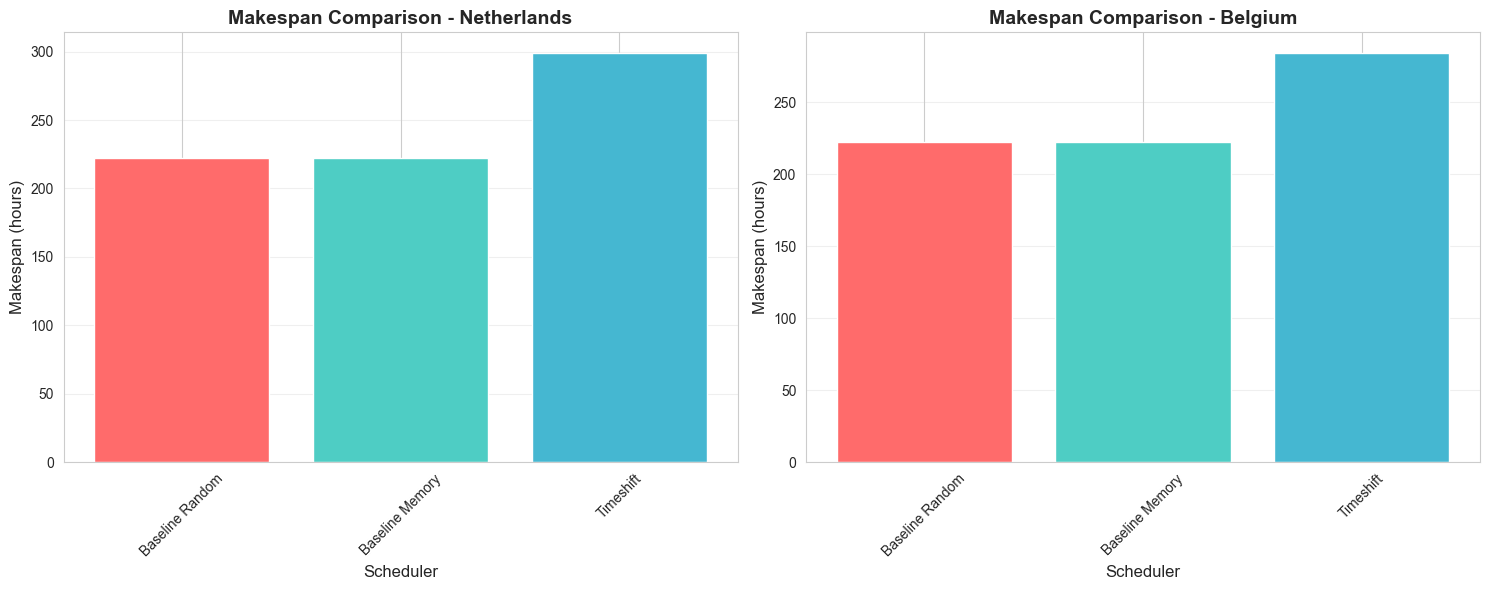

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, topo in enumerate(topologies.values()):
    topo_data = df_metrics[df_metrics['Topology'] == topo]
    
    axes[idx].bar(topo_data['Scheduler'], topo_data['Makespan (hours)'], 
                  color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
    axes[idx].set_title(f'Makespan Comparison - {topo}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Makespan (hours)', fontsize=12)
    axes[idx].set_xlabel('Scheduler', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Carbon Emissions Comparison

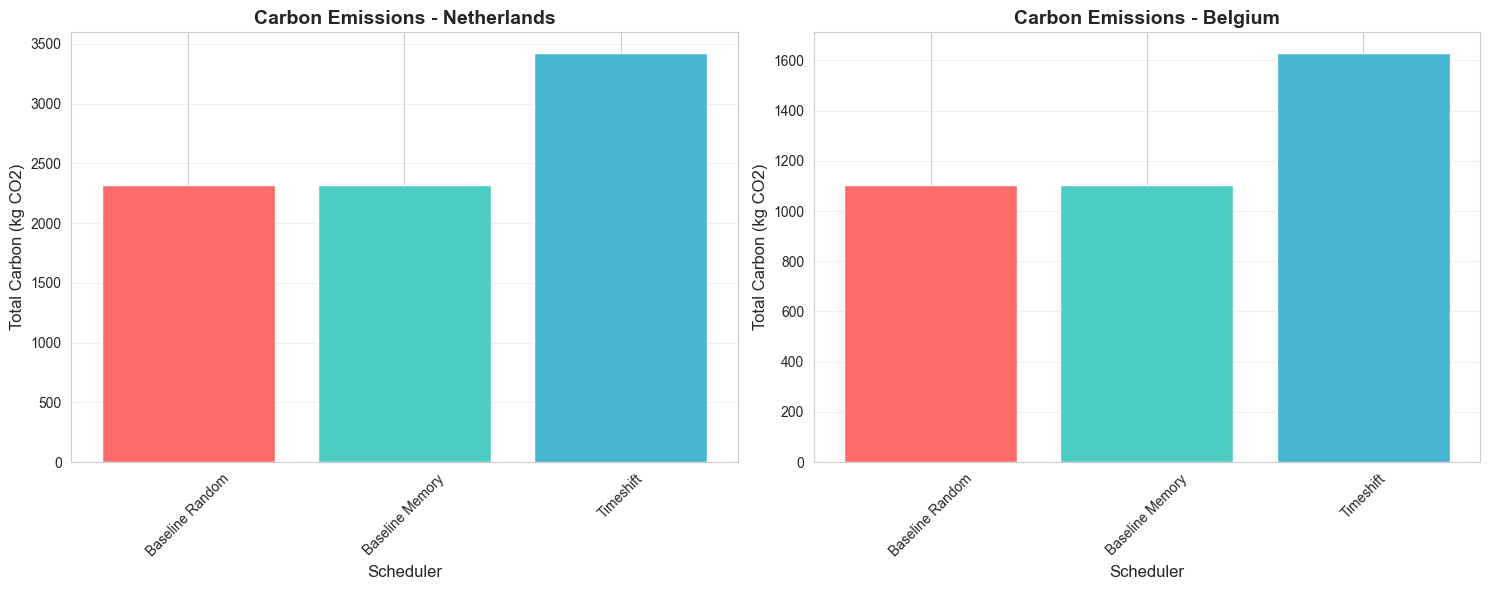

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, topo in enumerate(topologies.values()):
    topo_data = df_metrics[df_metrics['Topology'] == topo]
    
    axes[idx].bar(topo_data['Scheduler'], topo_data['Total Carbon (kg CO2)'], 
                  color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
    axes[idx].set_title(f'Carbon Emissions - {topo}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Total Carbon (kg CO2)', fontsize=12)
    axes[idx].set_xlabel('Scheduler', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Resource Utilization

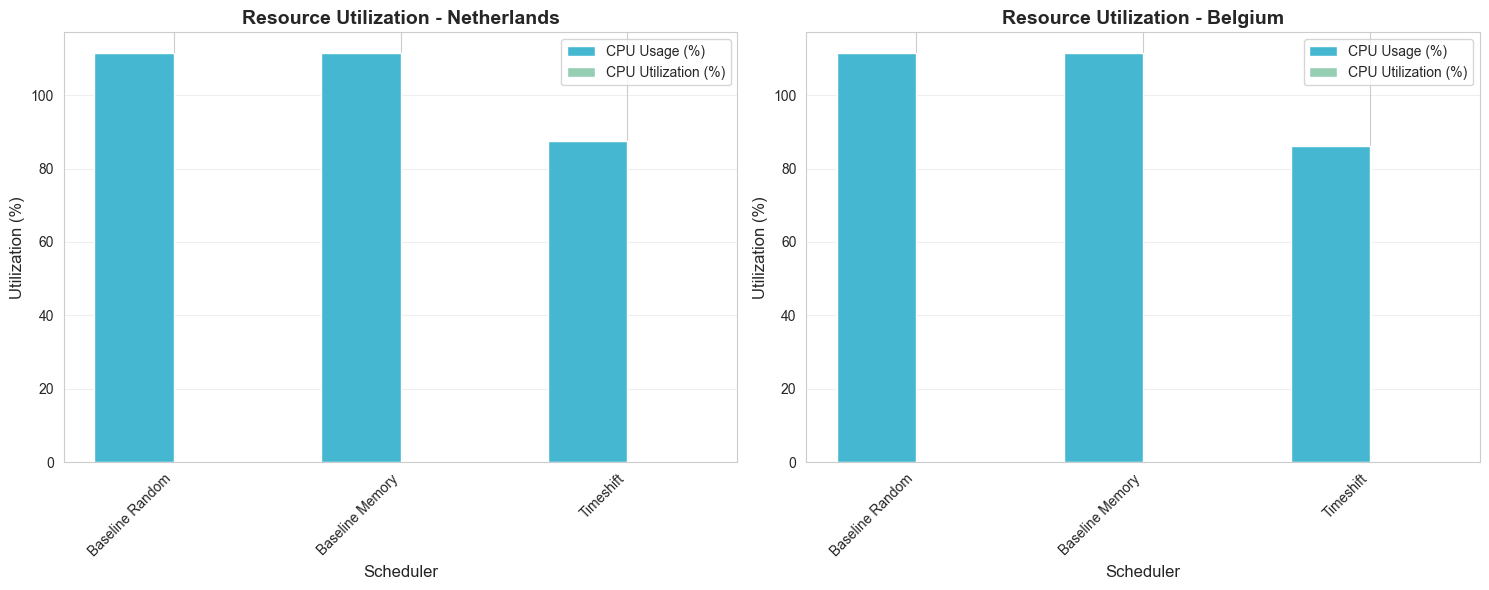

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, topo in enumerate(topologies.values()):
    topo_data = df_metrics[df_metrics['Topology'] == topo]
    
    x = np.arange(len(topo_data))
    width = 0.35
    
    # Use Avg CPU Usage (absolute value) and Avg CPU Utilization (%)
    axes[idx].bar(x - width/2, topo_data['Avg CPU Usage'] * 100, width, 
                  label='CPU Usage (%)', color='#45B7D1')
    axes[idx].bar(x + width/2, topo_data['Avg CPU Utilization (%)'], width, 
                  label='CPU Utilization (%)', color='#96CEB4')
    
    axes[idx].set_title(f'Resource Utilization - {topo}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Utilization (%)', fontsize=12)
    axes[idx].set_xlabel('Scheduler', fontsize=12)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(topo_data['Scheduler'], rotation=45, ha='right')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.4 Energy Consumption

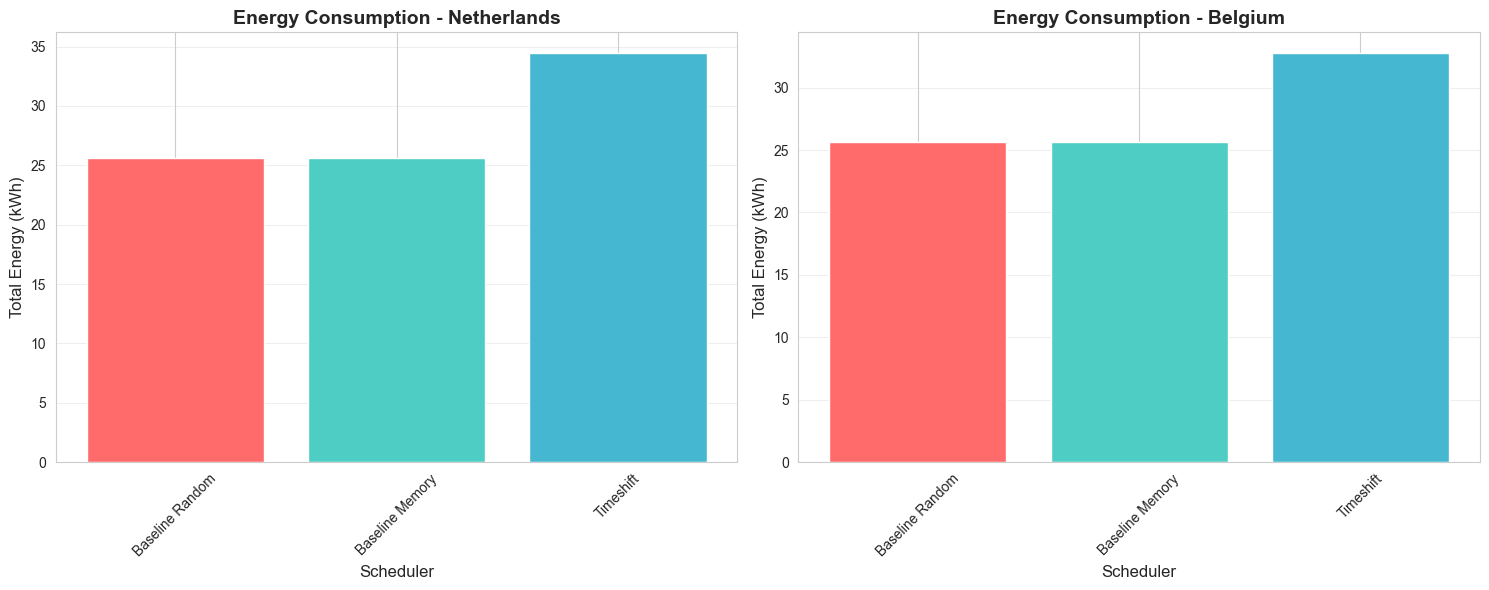

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, topo in enumerate(topologies.values()):
    topo_data = df_metrics[df_metrics['Topology'] == topo]
    
    axes[idx].bar(topo_data['Scheduler'], topo_data['Total Energy (kWh)'], 
                  color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
    axes[idx].set_title(f'Energy Consumption - {topo}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Total Energy (kWh)', fontsize=12)
    axes[idx].set_xlabel('Scheduler', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.5 Performance Summary

Calculate percentage improvements relative to baseline.

In [15]:

print("\n" + "="*100)
print("PERFORMANCE IMPROVEMENTS RELATIVE TO BASELINE RANDOM SCHEDULER")
print("="*100 + "\n")

for topo in topologies.values():
    print(f"\n{topo.upper()}:")
    print("-" * 50)
    
    topo_data = df_metrics[df_metrics['Topology'] == topo].copy()
    baseline = topo_data[topo_data['Scheduler'] == 'Baseline Random'].iloc[0]
    
    for _, row in topo_data.iterrows():
        if row['Scheduler'] == 'Baseline Random':
            continue
        
        print(f"\n{row['Scheduler']}:")
        
        makespan_improvement = ((baseline['Makespan (hours)'] - row['Makespan (hours)']) / baseline['Makespan (hours)']) * 100
        carbon_improvement = ((baseline['Total Carbon (kg CO2)'] - row['Total Carbon (kg CO2)']) / baseline['Total Carbon (kg CO2)']) * 100
        energy_improvement = ((baseline['Total Energy (kWh)'] - row['Total Energy (kWh)']) / baseline['Total Energy (kWh)']) * 100
        
        print(f"  Makespan: {makespan_improvement:+.2f}% ({row['Makespan (hours)']:.2f} vs {baseline['Makespan (hours)']:.2f} hours)")
        print(f"  Carbon: {carbon_improvement:+.2f}% ({row['Total Carbon (kg CO2)']:.2f} vs {baseline['Total Carbon (kg CO2)']:.2f} kg)")
        print(f"  Energy: {energy_improvement:+.2f}% ({row['Total Energy (kWh)']:.2f} vs {baseline['Total Energy (kWh)']:.2f} kWh)")

print("\n" + "="*100)


PERFORMANCE IMPROVEMENTS RELATIVE TO BASELINE RANDOM SCHEDULER


NETHERLANDS:
--------------------------------------------------

Baseline Memory:
  Makespan: +0.00% (222.44 vs 222.44 hours)
  Carbon: +0.00% (2316.71 vs 2316.71 kg)
  Energy: +0.00% (25.64 vs 25.64 kWh)

Timeshift:
  Makespan: -34.49% (299.16 vs 222.44 hours)
  Carbon: -47.90% (3426.34 vs 2316.71 kg)
  Energy: -34.47% (34.48 vs 25.64 kWh)

BELGIUM:
--------------------------------------------------

Baseline Memory:
  Makespan: +0.00% (222.44 vs 222.44 hours)
  Carbon: +0.00% (1103.90 vs 1103.90 kg)
  Energy: +0.00% (25.64 vs 25.64 kWh)

Timeshift:
  Makespan: -27.90% (284.50 vs 222.44 hours)
  Carbon: -47.68% (1630.24 vs 1103.90 kg)
  Energy: -27.88% (32.79 vs 25.64 kWh)



---
## 7. Detailed Scheduler Analysis

Visualize individual scheduler behavior with Gantt charts and carbon intensity.


Gantt Chart: Baseline Random
Displaying 120 tasks (IDs 0-119)


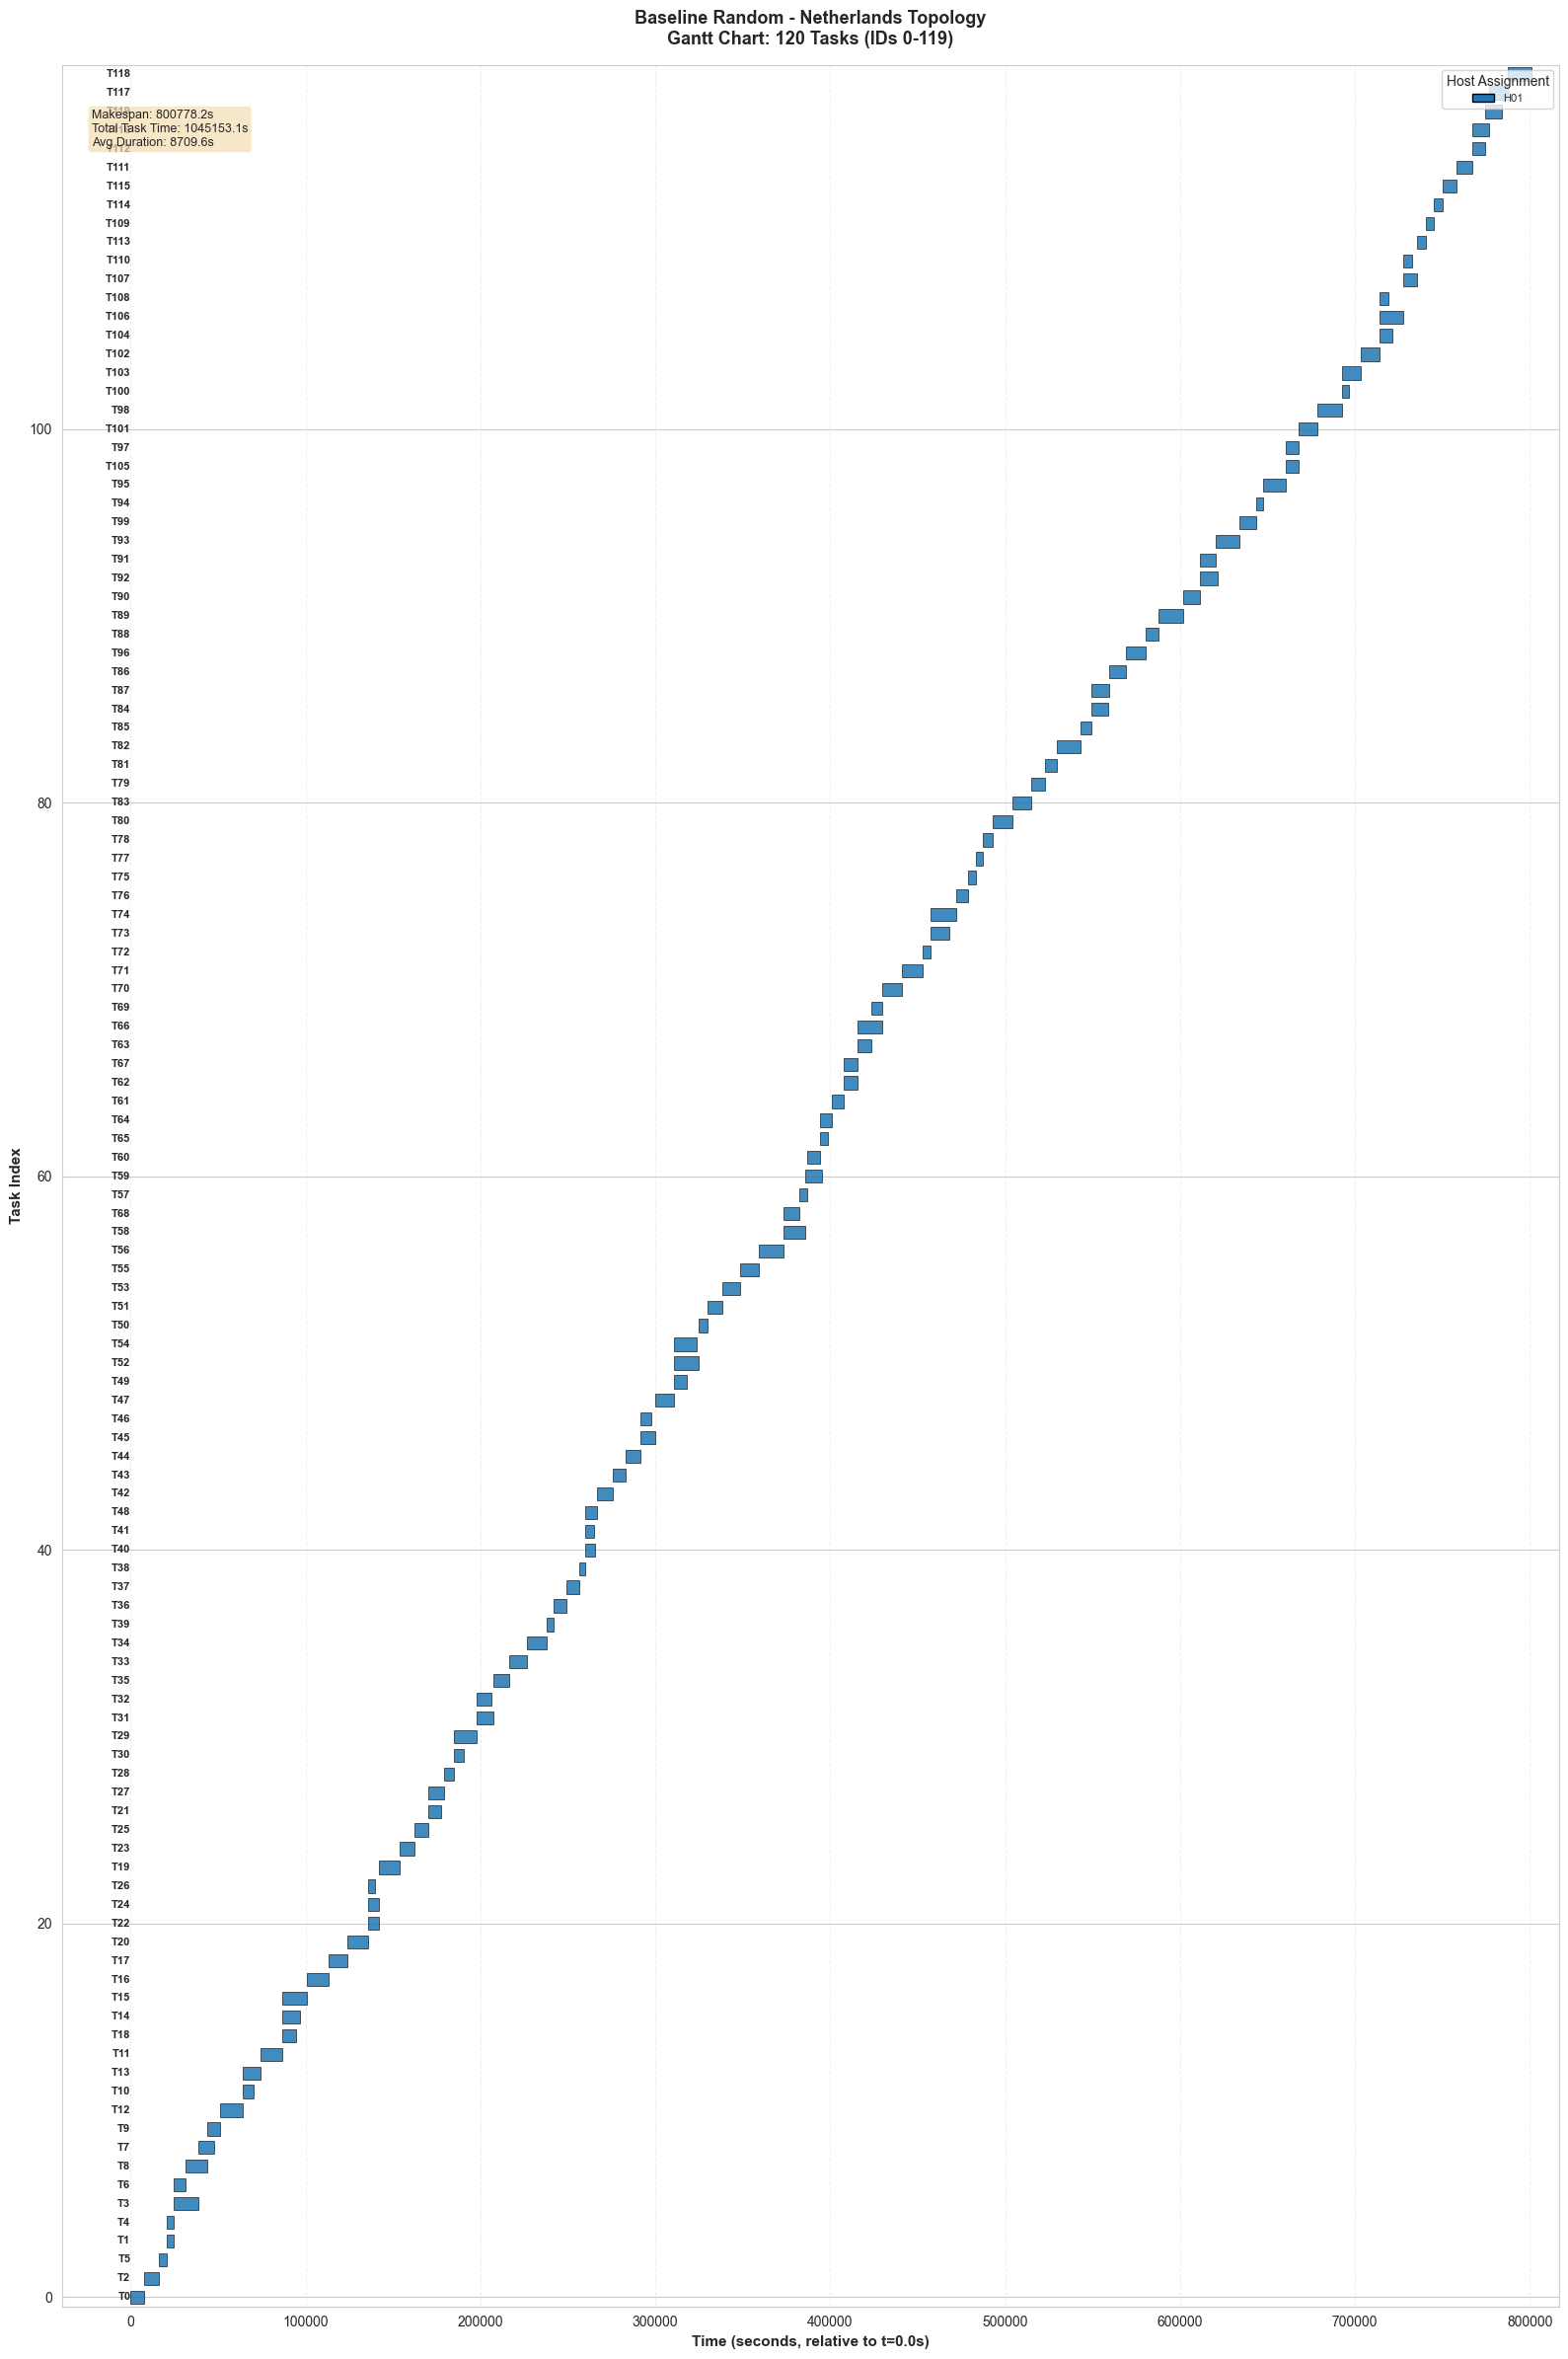


Gantt Chart: Baseline Memory
Displaying 120 tasks (IDs 0-119)


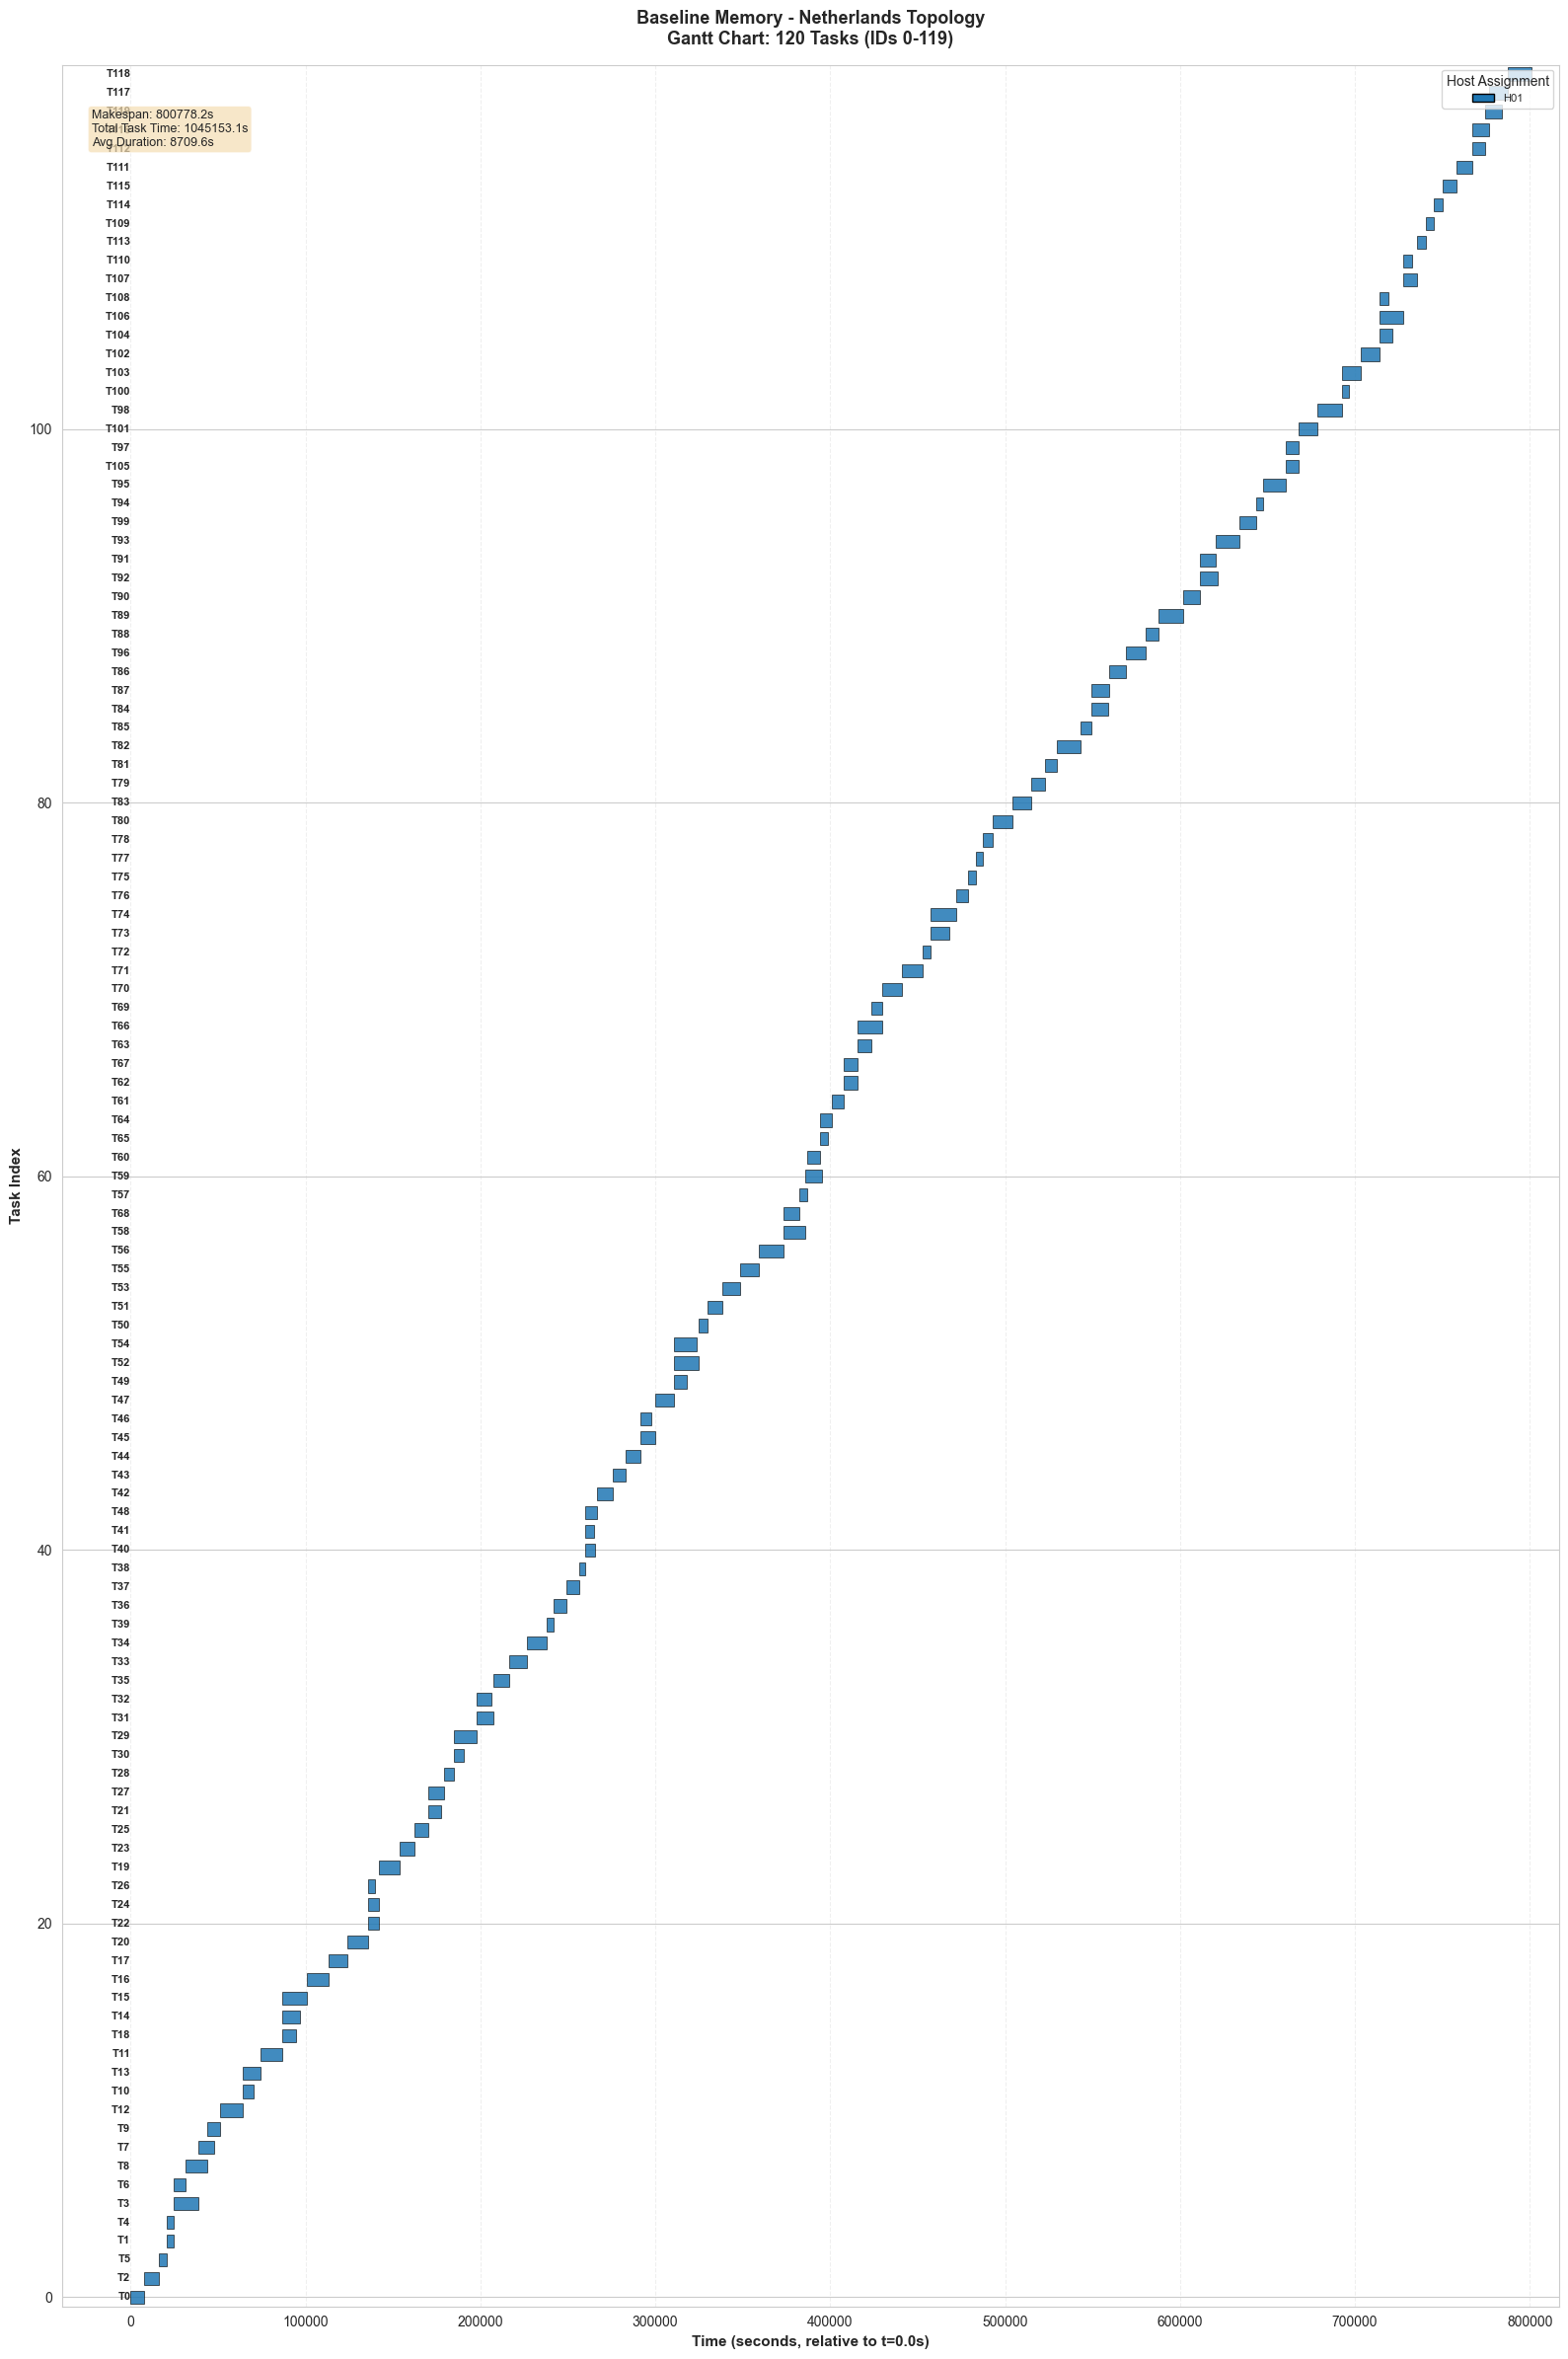


Gantt Chart: Workflow-Aware


KeyError: 'Netherlands'

In [16]:
# Generate Gantt charts for all schedulers
schedulers_to_visualize = ["Baseline Random", "Baseline Memory", "Workflow-Aware", 
                           "Carbon-Aware", "Timeshift"]

for scheduler in schedulers_to_visualize:
    print(f"\n{'='*80}")
    print(f"Gantt Chart: {scheduler}")
    print('='*80)
    fig = create_gantt_chart(scheduler, "Netherlands", max_tasks=500, show_deadline=False)
    if fig:
        plt.show()
    plt.close('all')  # Free memory

### 7.1 Gantt Charts with Carbon Intensity Overlay


Gantt + Carbon Intensity: Carbon-Aware
 Displaying 120 tasks


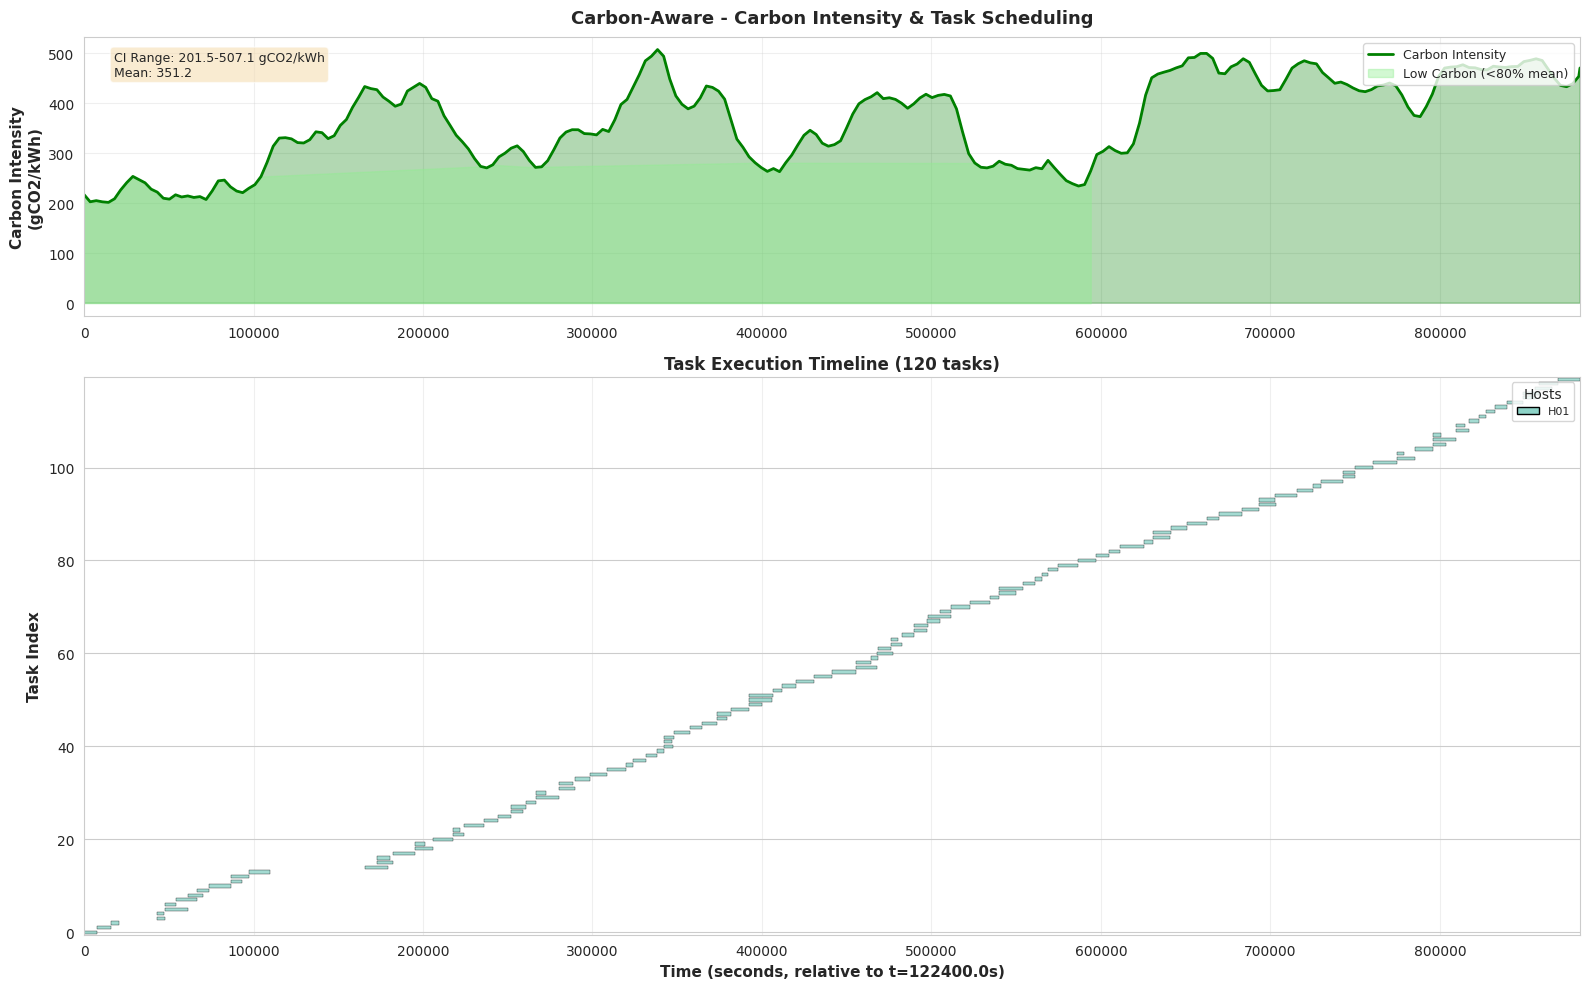


Gantt + Carbon Intensity: Timeshift
 Displaying 120 tasks


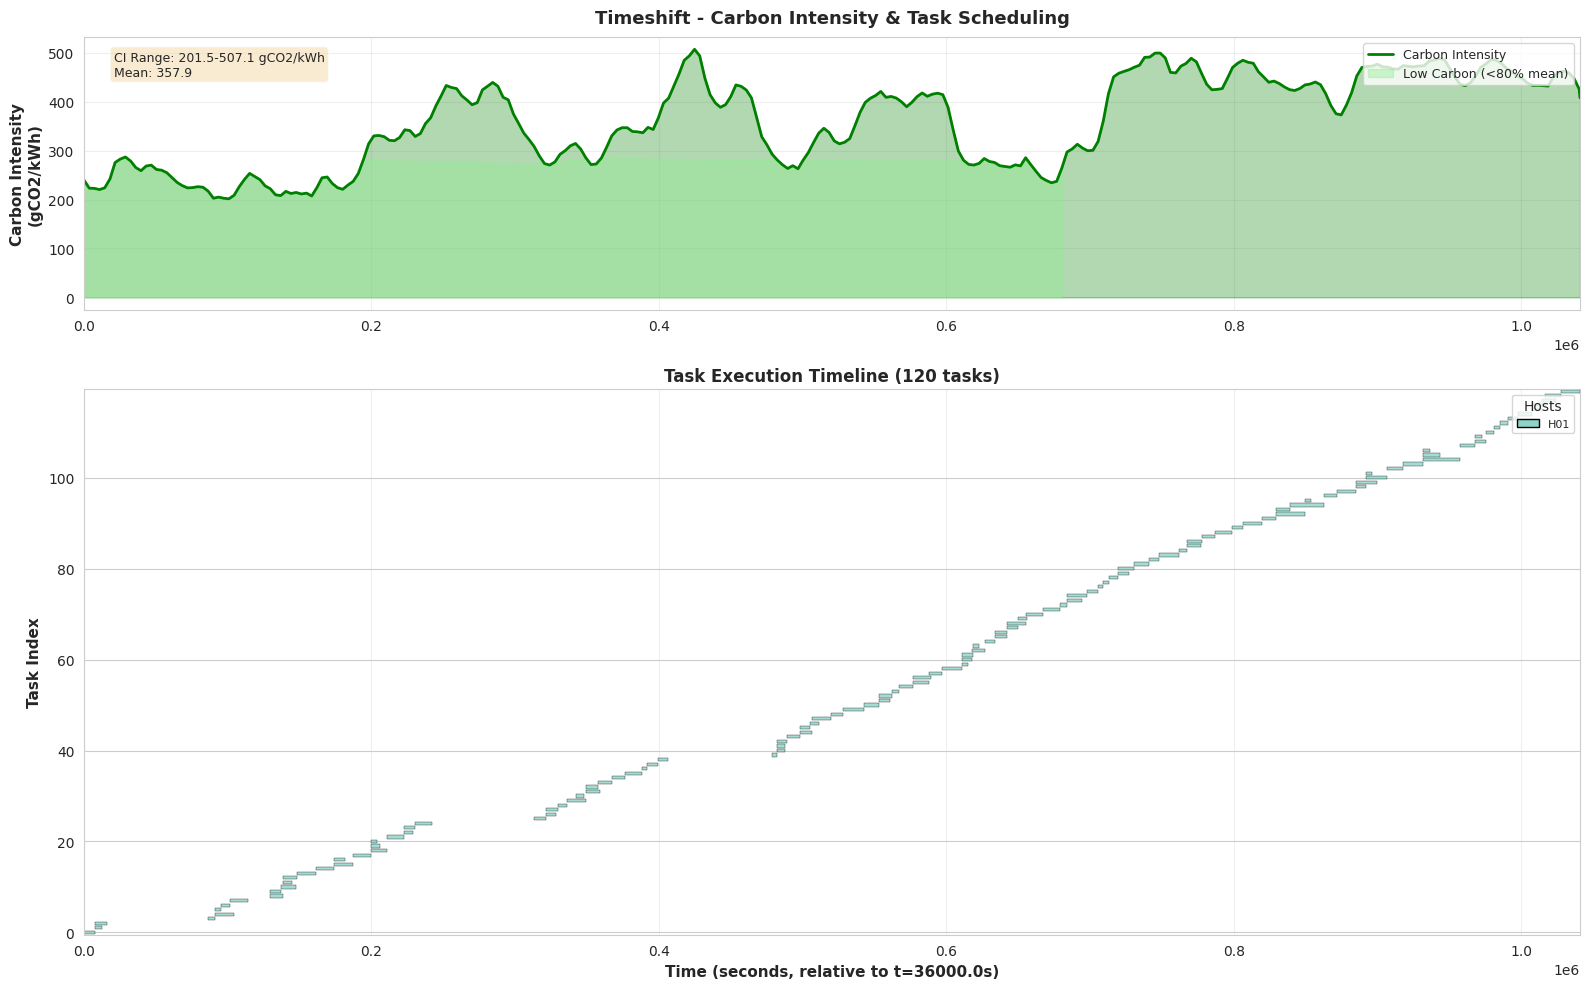

In [64]:
# Generate Gantt charts with carbon intensity for carbon-aware schedulers
carbon_schedulers = ["Carbon-Aware", "Timeshift"]

for scheduler in carbon_schedulers:
    print(f"\n{'='*80}")
    print(f"Gantt + Carbon Intensity: {scheduler}")
    print('='*80)
    fig = plot_gantt_with_carbon_intensity(scheduler, "Netherlands", max_tasks=500, show_deadline=False)
    if fig:
        plt.show()
    plt.close('all')  # Free memory

### Enhanced Gantt Chart with Carbon Intensity

Visualize task scheduling alongside carbon intensity timeline to see carbon-aware decisions.

#### Optional: Show Deadline on Charts

By default, deadline visualization is **disabled** to prevent x-axis squishing. You can enable it with `show_deadline=True`:

```python
# Example with deadline visible (will extend x-axis significantly)
fig = plot_gantt_with_carbon_intensity("Carbon-Aware", "Netherlands", 
                                       max_tasks=80, show_deadline=True)
```

**Note**: Since the deadline is very far in the future (1641346072381 ms ≈ Jan 2022 epoch time), enabling it will make task details harder to see.

### 7.2 Multi-Scheduler Comparison with Carbon Intensity

Compare multiple schedulers side-by-side with shared carbon intensity overlay to see how each responds to carbon changes.


Multi-Scheduler Comparison - All Schedulers


/tmp/ipykernel_19919/2109783678.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


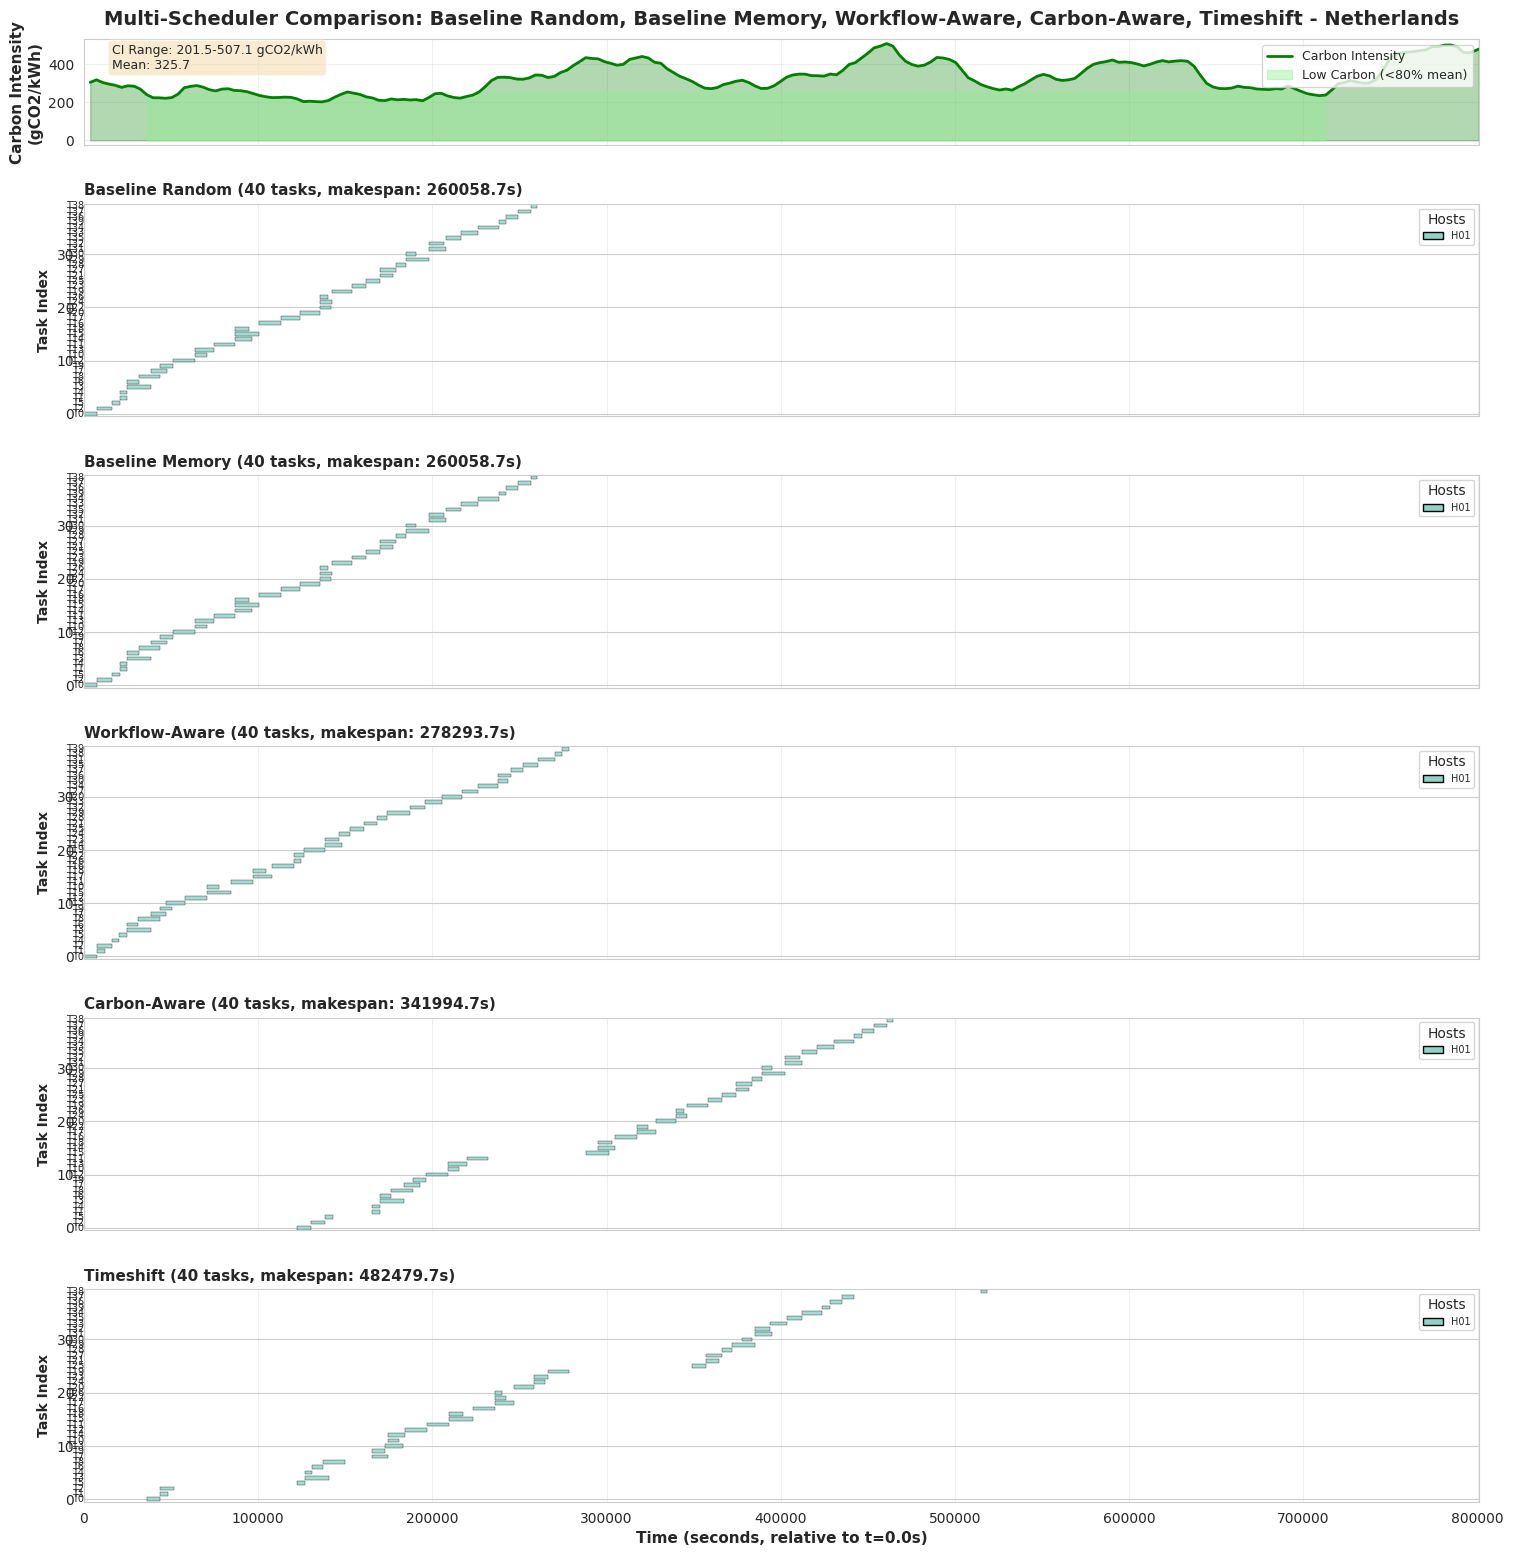

In [65]:
# Compare all schedulers with shared carbon intensity
print("\n" + "="*80)
print("Multi-Scheduler Comparison - All Schedulers")
print("="*80)

all_schedulers = ["Baseline Random", "Baseline Memory", "Workflow-Aware", "Carbon-Aware", "Timeshift"]
fig = plot_multi_scheduler_gantt_with_carbon(all_schedulers, "Netherlands", max_tasks=40, show_deadline=False)
if fig:
    plt.show()
plt.close('all')


Carbon-Aware Schedulers Comparison


/tmp/ipykernel_19919/2109783678.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


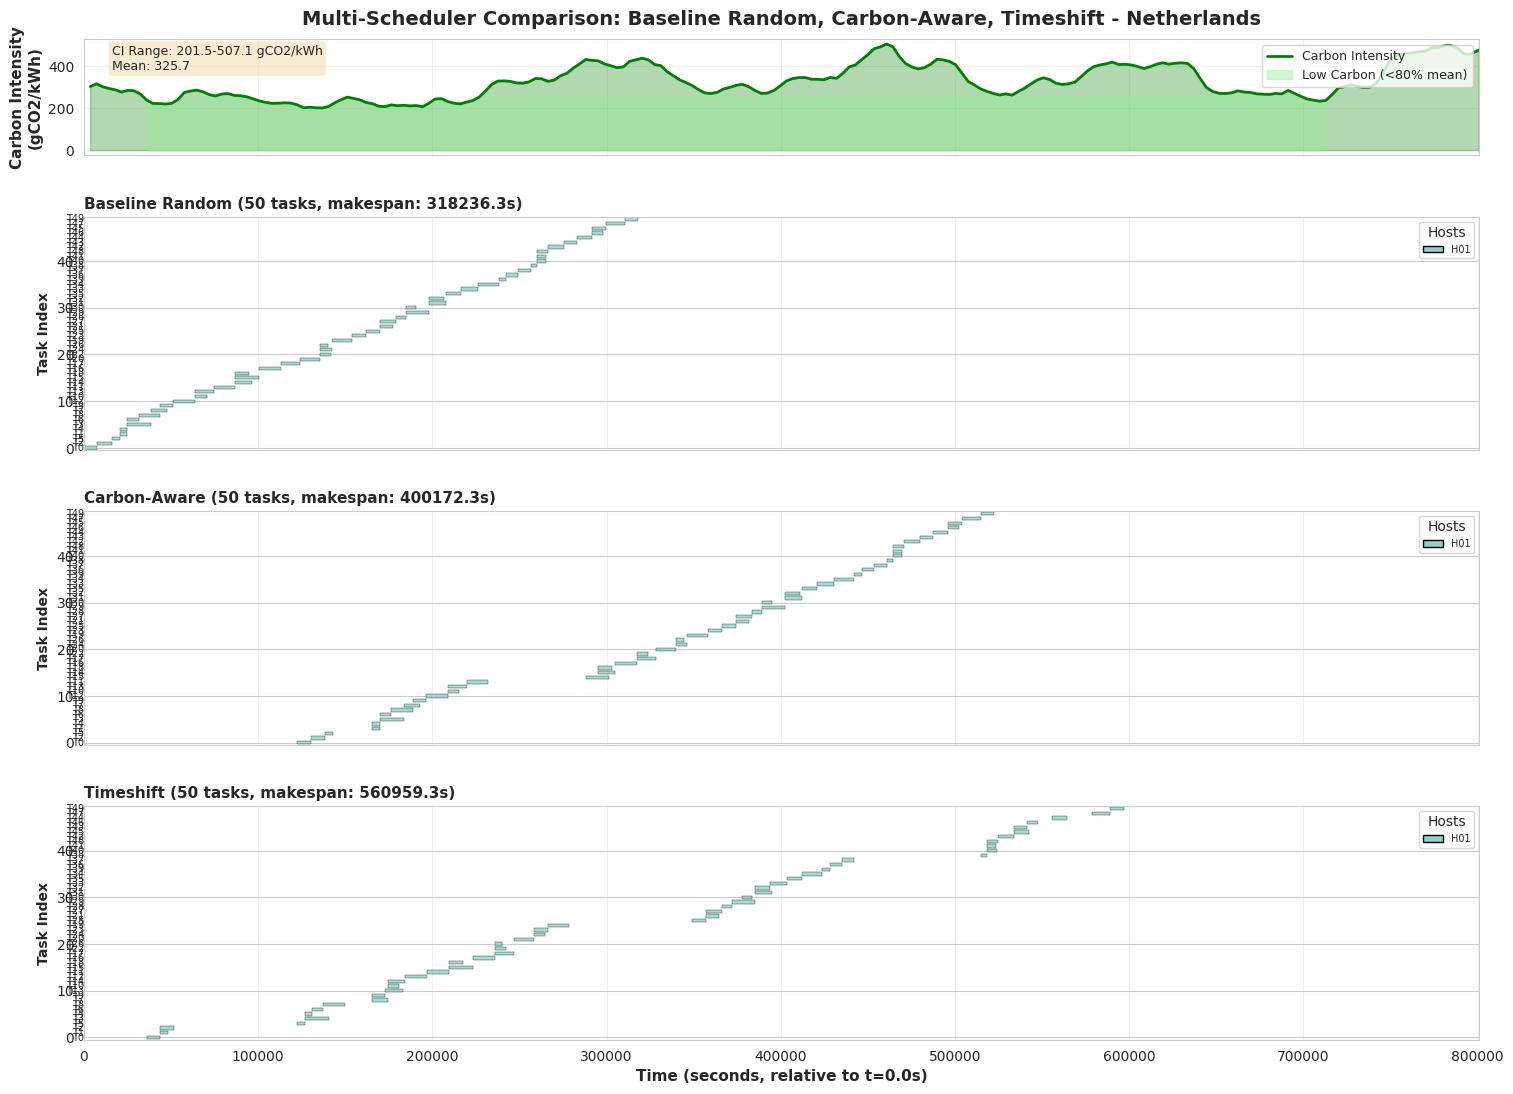

In [66]:
# Compare just carbon-aware schedulers for detailed analysis
print("\n" + "="*80)
print("Carbon-Aware Schedulers Comparison")
print("="*80)

carbon_schedulers = ["Baseline Random", "Carbon-Aware", "Timeshift"]
fig = plot_multi_scheduler_gantt_with_carbon(carbon_schedulers, "Netherlands", max_tasks=50, show_deadline=False)
if fig:
    plt.show()
plt.close('all')

### Carbon-Aware Decision Analysis

Visualize when and why the carbon-aware scheduler delays tasks to wait for lower carbon intensity.

---
## 9. Export Results

Save metrics to CSV for further analysis.

---
## 8. Timeshift Scheduler Deep Dive

Detailed analysis of the Timeshift scheduler's carbon-aware behavior.

In [67]:
# Compare carbon and energy metrics for all schedulers
print("\n" + "="*100)
print("TIMESHIFT SCHEDULER COMPARISON - NETHERLANDS")
print("="*100 + "\n")

topo_data = df_metrics[df_metrics['Topology'] == 'Netherlands'].copy()
topo_data = topo_data[['Scheduler', 'Makespan (hours)', 'Avg Wait Time (hours)', 
                        'Total Energy (kWh)', 'Total Carbon (kg CO2)']]

# Sort by carbon emissions
topo_data = topo_data.sort_values('Total Carbon (kg CO2)')
print(topo_data.to_string(index=False))

# Calculate improvements
baseline = topo_data[topo_data['Scheduler'] == 'Baseline Random'].iloc[0]
print("\n" + "-"*100)
print("IMPROVEMENTS RELATIVE TO BASELINE RANDOM:")
print("-"*100)

for _, row in topo_data.iterrows():
    if row['Scheduler'] == 'Baseline Random':
        continue
    
    carbon_improvement = ((baseline['Total Carbon (kg CO2)'] - row['Total Carbon (kg CO2)']) / baseline['Total Carbon (kg CO2)']) * 100
    makespan_change = ((row['Makespan (hours)'] - baseline['Makespan (hours)']) / baseline['Makespan (hours)']) * 100
    wait_time_change = ((row['Avg Wait Time (hours)'] - baseline['Avg Wait Time (hours)']) / baseline['Avg Wait Time (hours)']) * 100
    
    print(f"\n{row['Scheduler']}:")
    print(f"  Carbon Reduction: {carbon_improvement:+.2f}%")
    print(f"  Makespan Change: {makespan_change:+.2f}%")
    print(f"  Wait Time Change: {wait_time_change:+.2f}%")

print("\n" + "="*100)


TIMESHIFT SCHEDULER COMPARISON - NETHERLANDS

      Scheduler  Makespan (hours)  Avg Wait Time (hours)  Total Energy (kWh)  Total Carbon (kg CO2)
 Workflow-Aware          220.6506                 3.3172             25.4350              2289.7549
Baseline Random          222.4384                 3.3062             25.6410              2316.7124
Baseline Memory          222.4384                 3.3062             25.6410              2316.7124
   Carbon-Aware          279.1984                 3.3727             32.1797              3136.0103
      Timeshift          299.1559                 3.5552             34.4795              3426.3379

----------------------------------------------------------------------------------------------------
IMPROVEMENTS RELATIVE TO BASELINE RANDOM:
----------------------------------------------------------------------------------------------------

Workflow-Aware:
  Carbon Reduction: +1.16%
  Makespan Change: -0.80%
  Wait Time Change: +0.33%

Baseline M

In [68]:
output_csv = f"{base_dir}/scheduler_comparison_experiments/comparison_results.csv"
df_metrics.to_csv(output_csv, index=False)
print(f"✅ Results saved to: {output_csv}")

✅ Results saved to: /home/energyless/scheduler_comparison_experiments/comparison_results.csv


---

## Notebook Summary

This notebook provides comprehensive scheduler comparison analysis for OpenDC.

### Structure

**Section 1: Workload Analysis** - Visualize workflow DAG, task statistics, and dependency structure

**Section 2: Run Experiments** - Execute all scheduler configurations in parallel

**Section 3: Load Results** - Import experimental data from parquet files

**Section 4: Calculate Metrics** - Compute performance metrics (makespan, carbon, energy, utilization)

**Section 5: Visualization Functions** - Define reusable charting functions:
- `create_gantt_chart()` - Task scheduling Gantt charts
- `plot_gantt_with_carbon_intensity()` - Gantt with carbon overlay

**Section 6: Comparative Visualizations** - Side-by-side scheduler comparisons:
- Makespan comparison
- Carbon emissions
- Resource utilization
- Energy consumption
- Performance summary statistics

**Section 7: Detailed Analysis** - Individual scheduler deep dives with visualizations

**Section 8: Timeshift Analysis** - Carbon-aware timeshift scheduler evaluation

**Section 9: Export** - Save results to CSV

### Key Functions

```python
create_gantt_chart(scheduler_name, topo_name, max_tasks=50, show_deadline=False)
```
Creates a Gantt chart showing task scheduling patterns.

```python
plot_gantt_with_carbon_intensity(scheduler_name, topo_name, max_tasks=50, show_deadline=False)
```
Creates dual-panel visualization with carbon intensity timeline and task scheduling.

### Output Files

- `comparison_results.csv` - Complete metrics for all schedulers and topologies

### Data Processing Notes

All visualization functions properly handle:
- Task state filtering (COMPLETED only)
- Deduplication by task_id
- Duration validation (0 < duration < 50000s)
- Relative time coordinates for clean charts
- Optional deadline visualization

### Next Steps

1. Review metrics in Section 6 to identify best-performing schedulers
2. Examine Gantt charts in Section 7 to understand scheduling behavior
3. Analyze carbon-aware decisions in Section 8
4. Use exported CSV for statistical analysis or reporting